In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

load_dotenv()

c:\Users\Ashutosh Pandey\Desktop\Machine Learning\LangGraph-In-Depth\LangGraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [3]:
# defining the max tokens
MAX_TOKENS = 33

In [4]:
def chat_node_trimmer(state: MessagesState):

    #triming before calling the messages

    messages = trim_messages(
        state['messages'],
        strategy='last', 
        token_counter=count_tokens_approximately, 
        max_tokens=MAX_TOKENS)
    
    print("Number of tokens in the messages:", count_tokens_approximately(messages=messages))
    
    response = LLM.invoke(messages)
    return {'messages': [response]}

In [5]:
# building the graph
graph = StateGraph(MessagesState)

graph.add_node("chat_node", chat_node_trimmer)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

memory = InMemorySaver()
Triming_STM = graph.compile(checkpointer=memory)

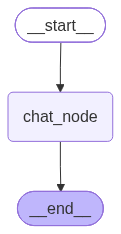

In [6]:
from IPython.display import Image
Image(Triming_STM.get_graph().draw_mermaid_png())

In [7]:
#creating the thread id for the chat
config1 = {"configurable": {"thread_id": "chat-2"}}

In [8]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "hi"}]}, config=config1)

Number of tokens in the messages: 5


In [9]:
result['messages'][-1].content

'Hello! How can I help you today?'

In [10]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "i am learning about langgraph"}]}, config=config1)

Number of tokens in the messages: 31


In [11]:
result['messages'][-1].content

'That’s great! LangGraph is a powerful library for building composable, state‑driven workflows (or “graphs”) on top of language models. Here’s a quick primer to get you started, plus some resources and tips for deeper exploration.\n\n---\n\n## 1️⃣ What Is LangGraph?\n\n| Aspect | Description |\n|--------|-------------|\n| **Core idea** | Treat a multi‑step LLM application as a **graph** of nodes (functions) that pass a mutable **state** object between them. |\n| **Why it helps** | - Clear separation of concerns (prompting, tool calls, branching, looping). <br>- Built‑in support for **conditional logic**, **retries**, **parallel execution**, and **memory**. <br>- Easy to visualize, test, and version. |\n| **Built on** | LangChain (v0.2+), but can be used with any LLM client (OpenAI, Anthropic, Azure, local models, etc.). |\n| **Execution model** | Synchronous or asynchronous; each node returns an updated `State` that drives the next edge. |\n\n---\n\n## 2️⃣ Core Concepts & API\n\n### a.

In [12]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "can you write a 10 line paragraph on langgraph?"}]},config=config1)

Number of tokens in the messages: 16


In [13]:
result["messages"][-1].content

'LangGraph is an open‑source Python framework that lets developers construct complex, state‑driven workflows for large language models (LLMs) with minimal boilerplate.  \nIt builds on LangChain’s modular components, adding a graph‑oriented abstraction where each node represents a distinct LLM call, tool invocation, or conditional branch.  \nDevelopers define the graph topology using a simple declarative syntax, then the engine orchestrates execution, handling context passing and error recovery automatically.  \nBecause the graph is explicit, debugging becomes visualizable: you can inspect the flow, replay specific nodes, and modify sub‑graphs without redeploying the entire pipeline.  \nLangGraph supports parallel execution of independent branches, enabling scalable batch processing and faster response times for multi‑step reasoning tasks.  \nBuilt‑in adapters for popular LLM providers (OpenAI, Anthropic, Cohere) and toolkits (retrieval, code execution, image generation) make integratio

In [14]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "hello how are you what are you doing can you name good leetcode algorithms for my interview tomorrow?"}]}, config1)

Number of tokens in the messages: 30


In [15]:
result["messages"][-1].content

'Hey! I’m doing great—thanks for asking. Good luck with your interview tomorrow! Below is a compact “cheat‑sheet” of the most frequently tested algorithmic concepts on LeetCode, along with a few representative problems you can solve to cement the ideas.\n\n---\n\n## 1. Core Data Structures & Patterns  \n\n| Concept | Why it matters | Key LeetCode examples |\n|---------|----------------|-----------------------|\n| **Two‑Pointer / Sliding Window** | Linear‑time scans for sorted arrays, strings, or subarray sums. | `3Sum` (16), `Longest Substring Without Repeating Characters` (3), `Minimum Size Subarray Sum` (209) |\n| **Hash Map / Set** | O(1) look‑ups for frequency, complement, or visited checks. | `Two Sum` (1), `Valid Anagram` (242), `Group Anagrams` (49) |\n| **Binary Search** | Log‑time search on monotonic / sorted data; also for answer‑search problems. | `Search in Rotated Sorted Array` (33), `Find Minimum in Rotated Sorted Array` (153), `Kth Smallest Element in a Sorted Matrix` (3